In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py

In [2]:
snapnum = 40

In [3]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [4]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [5]:
h = 0.6774

In [6]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [7]:
group_sfr = np.log10(halos["GroupSFR"])

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:1: RuntimeWarning: divide by zero encountered in log10
  """Entry point for launching an IPython kernel.


In [20]:
group_pos = halos["GroupPos"]/1e3

In [8]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

10
<class 'dict'>


In [9]:
mask_mass = (mvir < 13.1) & (mvir > 13)

In [12]:
groupids = np.arange(0,len(mvir), 1)[mask_mass]

In [21]:
sub_pos = subhalos["SubhaloPos"]/1e3

In [45]:
with open("sats_in_r0.5.txt", "w") as f:
    for groupid in groupids:
        mask_haloid = (subhalos["SubhaloGrNr"] == groupid) & (subhalos["SubhaloSFR"] > 0)
        pos_rel = sub_pos[mask_haloid] - group_pos[groupid]

        pos_rel_r = np.linalg.norm(pos_rel, axis=1)

        mask_r = (pos_rel_r < 0.5) & (pos_rel_r > 0)
        #print(np.sum(mask_r))
        #print(len(pos_rel_r))
        #print(np.sum((subhalos["SubhaloGrNr"] == groupid)))

        pos_arr = pos_rel[mask_r] + group_pos[groupid]

        ngal = np.sum(mask_r)
        for igal in range(ngal):
            print(groupid, 13, pos_arr[:,0][igal], pos_arr[:,1][igal], pos_arr[:,2][igal], np.log10(subhalos["SubhaloSFR"][mask_haloid][mask_r][igal]), file=f)

    

In [46]:
with open("toy_models/tng_sats_in_r0.5_sum.txt", "w") as f:
    for groupid in groupids:
        mask_haloid = (subhalos["SubhaloGrNr"] == groupid) & (subhalos["SubhaloSFR"] > 0)
        pos_rel = sub_pos[mask_haloid] - group_pos[groupid]

        pos_rel_r = np.linalg.norm(pos_rel, axis=1)

        mask_r = (pos_rel_r < 0.5) & (pos_rel_r > 0)
        #print(np.sum(mask_r))
        #print(len(pos_rel_r))
        #print(np.sum((subhalos["SubhaloGrNr"] == groupid)))

        pos_arr = pos_rel[mask_r] + group_pos[groupid]

        ngal = np.sum(mask_r)
        print(groupid, 13, group_pos[groupid][0], group_pos[groupid][1], group_pos[groupid][2], ngal, file=f)


(array([ 9.,  9., 12.,  4., 11., 12.,  9.,  7., 18.,  4.]),
 array([0.        , 0.2632028 , 0.5264056 , 0.78960836, 1.0528111 ,
        1.3160139 , 1.5792167 , 1.8424195 , 2.1056223 , 2.368825  ,
        2.6320279 ], dtype=float32),
 <BarContainer object of 10 artists>)

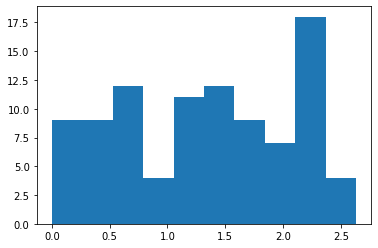

In [32]:
plt.hist(pos_rel_r)

In [ ]:
cent_mask_all = np.full(len(subhalos["SubhaloSFR"]), False)
cent_mask_all[halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]] = True

In [ ]:
sat_sfrs = subhalos["SubhaloSFR"][~cent_mask_all]

In [ ]:
sat_mass = subhalos["SubhaloMass"][~cent_mask_all]*1e10

In [ ]:
sat_ids = subhalos["SubhaloGrNr"][~cent_mask_all]
unique_ids, indices = np.unique(sat_ids, return_index=True)

In [ ]:
sum_sfrs1 = np.add.reduceat(sat_sfrs, indices)

In [ ]:
sum_sfrs = np.zeros(len(halos["GroupFirstSub"]))
sum_sfrs[unique_ids] = sum_sfrs1
sum_sfrs = np.log10(sum_sfrs)

/cosma/local/Python/3.6.5/lib/python3.6/site-packages/ipykernel_launcher.py:3: RuntimeWarning: divide by zero encountered in log10
  This is separate from the ipykernel package so we can avoid doing imports until
